In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### a=8.4 Jrt=-1.2/-0.8 快慢纺锤更大的区别 修改scale2=0.0005
- scale2=0.0005也做
- 6.22汇报时的参数全探索基础上 修改scale2=0.0005 无噪声 初始值随机

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10              # 每个参数组合运行的次数
c2tsc = 0.8              # 固定 c2tsc
scale2 = 0.0005          # 固定 scale2
a = 8.4                  # 固定 a
Jrt = -0.8               # 固定 Jrt

Jet_max = 1.98 * 75   # 148.5
Jer_max = 3.24 * 50   # 162

# 对数间隔：小值变化更精细
#Jet_list = np.logspace(np.log10(Jet_max), np.log10(Jet_max*2), 10)  # 从 0.1 开始，避免 0
Jet_list = np.logspace(np.log10(1.0), np.log10(Jet_max), 40)  # 从 0.1 开始，避免 0

#Jet_list = np.logspace(np.log10(6.5), np.log10(Jet_max), 40)  # 从 0.1 开始，避免 0
#Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 10)  # 从 0.1 开始，避免 0
#Jet_list = np.insert(Jet_list, 0, 0)  # 如果想包含 0，手动加上

Jer_list = [Jer_max]
#Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)
#Jer_min = Jer_list[-2]
#Jer_list = np.logspace(np.log10(Jer_min), np.log10(Jer_max), 5)
#Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 5)
#Jer_list = np.insert(Jer_list, 0, 0)

print(f"Jet 范围: {Jet_list}")
print(f"Jer 范围: {Jer_list}")
print(f"总参数组合数: {len(Jet_list) * len(Jer_list)}")
print(f"总运行次数: {len(Jet_list) * len(Jer_list) * n_runs}")



Jet 范围: [  1.           1.13680322   1.29232155   1.4691153    1.670095
   1.89856936   2.15829976   2.45356211   2.7892173    3.17079119
   3.60456563   4.0976818    4.65825785   5.2955225    6.01996701
   6.84351786   7.77973312   8.84402563  10.05391678  11.42932494
  12.99289335  14.77036295  16.79099611  19.08805839  21.69936617
  24.66790925  28.04255858  31.87887079  36.24000285  41.1977518
  46.83373675  53.24074258  60.52424741  68.80415912  78.21678939
  88.91709775 101.08124272 114.90948184 130.62946855 148.5       ]
Jer 范围: [162.0]
总参数组合数: 40
总运行次数: 400


In [3]:

# 创建保存目录
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_0x8"
os.makedirs(DATA_DIR, exist_ok=True)

# 统计已完成文件，支持断点续跑
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

total_tasks = len(Jet_list) * len(Jer_list) * n_runs
completed = 0
skipped = 0

for Jet_val in Jet_list:
    for Jer_val in Jer_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(DATA_DIR, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                skipped += 1
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet_val
            params["Jer"] = Jer_val

            # 修改 a 和 Jrt
            params["VT_t"] = 26 -a#26 -9
            params["VT_r"] = 23 -a#23
            params["VB_t"] = 15 -a#15
            params["VB_r"] = 15 -a#15
            params["Jrt"] = Jrt # -0.5
                        
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "Jet": Jet_val,
                "Jer": Jer_val,
                "seed": seed
            })
            completed += 1
            print(f"Saved: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed} (已完成 {completed})")

print(f"\n完成！新运行: {completed}, 跳过: {skipped}")
print(f"数据保存在: {DATA_DIR}")

已存在 190 个文件，将跳过它们
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_1.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_2.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_3.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_4.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_5.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_6.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_7.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_8.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_9.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_1.0000_Jer_162.0000_seed_10.npy
Saved: Jet=1.1368, Jer=162.0000, seed=1 (已完成 1)
Saved: Jet=1.1368, Jer=162.0000, seed=2 (已完成 2)
Saved: Jet=1.1368, Jer=162.0000, seed=3 (已完成 3)
Saved: Jet=1.1368, Jer=162.0000, seed=4 (已完成 4)
Saved: Jet=1.1368, Jer=162.0000, seed=5 (已完成 5)
Saved: Jet=1.1368, Jer=162.0000, seed=6 (已完成 6)
Saved: Jet=1.1368, Jer=162.0000, 

In [4]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 没有wax&wane的原本分析版本 

In [5]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_0x8"           # 数据文件夹名
#DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_1x2"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5*2)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_CSV = f"data/analysis_data/spindles_{DATA_FOLDER}_explore.csv"

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase):
    """处理纺锤波检测结果，返回列表"""
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
            "phase_at_end": slow_phase[end_idx],
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出文件: {OUTPUT_CSV}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        PARAM1_NAME: Jet_val,
        PARAM2_NAME: Jer_val,
        "seed": seed,
    }
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印参数范围
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 550 个文件
限定 Jet 范围: (0, 297.0)
限定 Jer 范围: (0, 162)
输出文件: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv
Processing: Jet=1.0000, Jer=162.0000, seed=1
Setting up low-pass filter at 3 Hz


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=7
Processing: Jet=1.0000, Jer=162.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成：快=9, 慢=2
Processing: Jet=9.2302, Jer=162.0000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=11, 慢=6
Processing: Jet=9.2302, Jer=162.0000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=10, 慢=4

总共检测到 4790 个纺锤波
快纺锤波: 3240
慢纺锤波: 1550
CSV 已保存: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.000500 ~ 0.000500
  Jet: 1.0000 ~ 297.0000
  Jer: 162.0000 ~ 162.0000

前几行:
   c2tsc  scale2  Jet    Jer  seed  type    start  peak_time      end  \
0    0.8  0.0005  1.0  162.0     1  fast   4.0927     4.4122   4.4958   
1    0.8  0.0005  1.0  162.0     1  fast   7.2893     7.4672   7.6186   
2    0.8  0.0005  1.0  162.0     1  fast   8.5627     9.1205   9.7716   
3    0.8  0.0005  1.0  162.0     1  fast  13.2171    13.3364  14.1230   
4    0.8  0.0005  1.0  162.0     1  slow   5.2693     5.4832   5.5806   

   duration  frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  
0    0.4031  13.364380   4.708939        3.031078      -1.471090     -0.521517  
1    0.3293  12.959658   3.358372        1.695449       3.100209     -3.073975  
2    1.2089  14.399506   4.900179        2.703391      -1.215341  

#### wax&wane

In [10]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_0x8"           # 数据文件夹名
#DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_1x2"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5*2)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_CSV = f"data/analysis_data/spindles_{DATA_FOLDER}_explore.csv"

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase, V_t=None):
    """
    处理纺锤波检测结果
    新增：从原始 V_t 中提取 start→peak 和 peak→end 的振幅
    """
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        overall_amplitude = row["Amplitude"]  # YASA 计算的整体振幅
        
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        
        # ===== 从原始 V_t 中计算 start→peak 和 peak→end 的振幅 =====
        # 截取信号片段
        start_segment = V_t[start_idx_sample:peak_idx_sample] if peak_idx_sample > start_idx_sample else np.array([0])
        end_segment = V_t[peak_idx_sample:end_idx_sample] if end_idx_sample > peak_idx_sample else np.array([0])
        
        # 计算各段的峰峰值振幅
        if len(start_segment) >= 2:
            start_to_peak_amp = np.max(start_segment) - np.min(start_segment)
        else:
            start_to_peak_amp = 0.0
        
        if len(end_segment) >= 2:
            peak_to_end_amp = np.max(end_segment) - np.min(end_segment)
        else:
            peak_to_end_amp = 0.0
        
        phase_start = slow_phase[start_idx]
        phase_peak = slow_phase[peak_idx]
        phase_end = slow_phase[end_idx]
        
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": overall_amplitude,              # 原有的整体振幅
            "start_to_peak_time": peak_time - start_time,
            "peak_to_end_time": end_time - peak_time,
            "start_to_peak_amp": start_to_peak_amp,      # 新增：上升段振幅
            "peak_to_end_amp": peak_to_end_amp,          # 新增：下降段振幅
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出文件: {OUTPUT_CSV}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        PARAM1_NAME: Jet_val,
        PARAM2_NAME: Jer_val,
        "seed": seed,
    }
    
    # 传入 V_t 用于计算分段振幅
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase, V_t))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase, V_t))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印新增字段示例
if len(result_df) > 0:
    print("\n新增字段示例（第一条记录）:")
    cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp', 'amplitude']
    for col in cols:
        if col in result_df.columns:
            print(f"  {col}: {result_df[col].iloc[0]:.6f}")

# 打印参数范围
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 550 个文件
限定 Jet 范围: (0, 297.0)
限定 Jer 范围: (0, 162)
输出文件: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv
Processing: Jet=1.0000, Jer=162.0000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=6, 慢=7
Processing: Jet=1.0000, Jer=162.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=7, 慢=2
Processing: Jet=1.0000, Jer=162.0000, seed=2
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成：快=9, 慢=2
Processing: Jet=9.2302, Jer=162.0000, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=11, 慢=6
Processing: Jet=9.2302, Jer=162.0000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=10, 慢=4

总共检测到 4790 个纺锤波
快纺锤波: 3240
慢纺锤波: 1550
CSV 已保存: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv

新增字段示例（第一条记录）:
  start_to_peak_time: 0.319500
  peak_to_end_time: 0.083600
  start_to_peak_amp: 5.603269
  peak_to_end_amp: 9.034728
  amplitude: 4.708939

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.000500 ~ 0.000500
  Jet: 1.0000 ~ 297.0000
  Jer: 162.0000 ~ 162.0000

前几行:
   c2tsc  scale2  Jet    Jer  seed  type    start  peak_time      end  \
0    0.8  0.0005  1.0  162.0     1  fast   4.0927     4.4122   4.4958   
1    0.8  0.0005  1.0  162.0     1  fast   7.2893     7.4672   7.6186   
2    0.8  0.0005  1.0  162.0     1  fast   8.5627     9.1205   9.7716   
3    0.8  0.0005  1.0  162.0     1  fast  13.2171    13.3364  14.1230   
4    0.8  0.0005  1.0  162.0     1  slow   5.2693     5.4832   5.5806   

   duration  frequency  amplitude  start_to_peak_time  peak_to_end_time  \
0    0.4031  13.364380   4.708939              0.3195            0.0836   
1  

#### 画图

总纺锤波数: 4790
Jet 范围: 1.00 ~ 297.00
Jer 范围: 162.00 ~ 162.00

使用的 Jet 值: [1.0, 1.1368, 1.2923, 1.4691, 1.6701, 1.743, 1.8986, 2.1583, 2.4536, 2.7892, 3.0381, 3.1708, 3.6046, 4.0977, 4.6583, 5.2955, 6.02, 6.8435, 7.7797, 8.844, 9.2302, 10.0539, 11.4293, 12.9929, 14.7704, 16.0885, 16.791, 19.0881, 21.6994, 24.6679, 28.0426, 31.8789, 36.24, 41.1978, 46.8337, 48.8788, 53.2407, 60.5242, 68.8042, 78.2168, 85.1968, 88.9171, 101.0812, 114.9095, 130.6295, 148.5, 160.3889, 173.2296, 187.0983, 202.0773, 218.2556, 235.7291, 254.6015, 274.9848, 297.0]
使用的 Jer 值: [162.0]

原始有效参数组合数: 55
过滤后有效参数组合数: 55


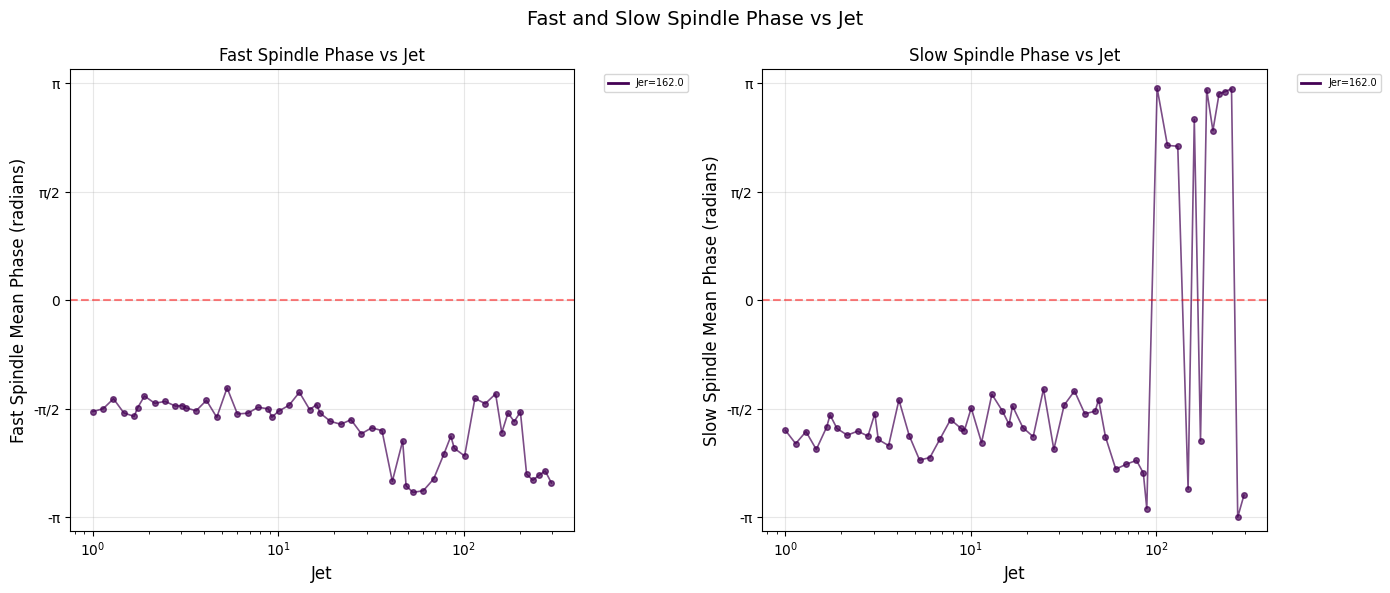

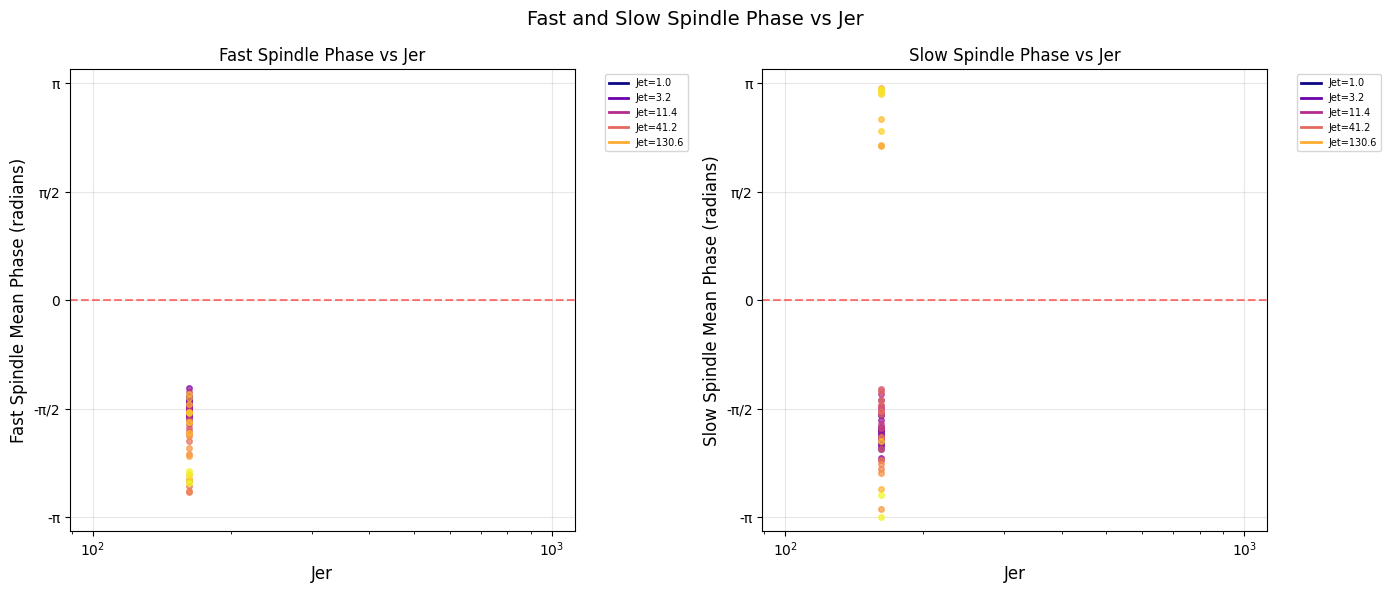

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
#df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_1x2_explore.csv")
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 和 Jer 值 ==========
Jet_values_all = sorted(df['Jet'].unique())
Jer_values_all = sorted(df['Jer'].unique())

# 去掉你不想显示的值（修改这里即可）
Jet_values_all = Jet_values_all#[:-1]  # 去掉最后一个（最大值）
Jer_values_all = Jer_values_all#[:-1]  # 去掉最后一个（最大值）

print(f"\n使用的 Jet 值: {Jet_values_all}")
print(f"使用的 Jer 值: {Jer_values_all}")

# ========== 计算每个 (Jet, Jer) 组合下快慢纺锤波的相位 ==========
fast_phase = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_phase')

slow_phase = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_phase')

fast_std = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_std')

slow_std = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_std')

# 合并
phase_df = pd.merge(fast_phase, slow_phase, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, fast_std, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, slow_std, on=['Jet', 'Jer'])
phase_df['phase_diff'] = phase_df['fast_phase'] - phase_df['slow_phase']
phase_df = phase_df.dropna()

# ========== 关键：用 Jet_values_all 和 Jer_values_all 过滤 phase_df ==========
phase_df_filtered = phase_df[
    (phase_df['Jet'].isin(Jet_values_all)) & 
    (phase_df['Jer'].isin(Jer_values_all))
].copy()

print(f"\n原始有效参数组合数: {len(phase_df)}")
print(f"过滤后有效参数组合数: {len(phase_df_filtered)}")

# ========== 图2：快慢纺锤波各自的相位 vs Jet ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_values_all)))

# 左图：快纺锤波相位 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['fast_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Jer={Jer_values_all[i]:.1f}') 
                   for i in range(0, len(Jer_values_all), max(1, len(Jer_values_all)//5))]
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['slow_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jet', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢纺锤波各自的相位 vs Jer ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_values_all)))

# 左图：快纺锤波相位 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['fast_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

legend_elements2 = [Line2D([0], [0], color=colors2[i], lw=2, label=f'Jet={Jet_values_all[i]:.1f}') 
                    for i in range(0, len(Jet_values_all), max(1, len(Jet_values_all)//5))]
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['slow_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jer', fontsize=14)
plt.tight_layout()
plt.show()

### 以下的csv名称未改

总纺锤波数: 4790
Jet 范围: 1.00 ~ 297.00
Jer 范围: 162.00 ~ 162.00

目标 Jer: 132, 实际最近值: 162.0000


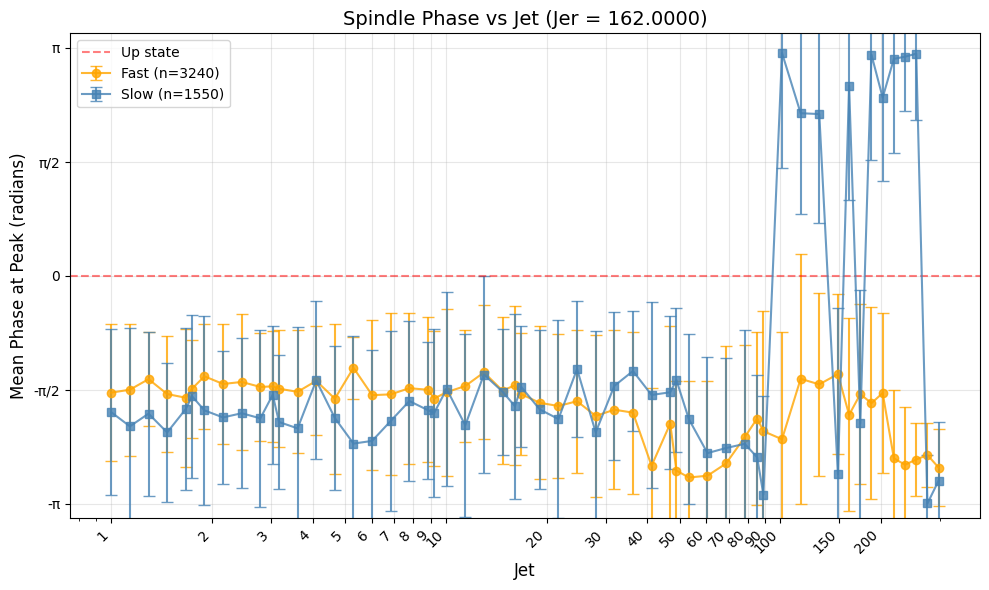


统计摘要 (Jer = 162.0000)
Jet=1.0000: Fast mean=-1.611±0.941 rad (n=54) Slow mean=-1.881±1.147 rad (n=19)
Jet=1.1368: Fast mean=-1.571±0.912 rad (n=70) Slow mean=-2.076±1.353 rad (n=30)
Jet=1.2923: Fast mean=-1.425±0.644 rad (n=68) Slow mean=-1.901±1.131 rad (n=24)
Jet=1.4691: Fast mean=-1.631±0.801 rad (n=59) Slow mean=-2.160±0.956 rad (n=26)
Jet=1.6701: Fast mean=-1.682±0.954 rad (n=68) Slow mean=-1.836±1.118 rad (n=30)
Jet=1.7430: Fast mean=-1.557±0.678 rad (n=57) Slow mean=-1.661±1.124 rad (n=31)
Jet=1.8986: Fast mean=-1.386±0.723 rad (n=57) Slow mean=-1.856±1.304 rad (n=32)
Jet=2.1583: Fast mean=-1.492±0.832 rad (n=73) Slow mean=-1.953±0.914 rad (n=30)
Jet=2.4536: Fast mean=-1.464±0.937 rad (n=68) Slow mean=-1.895±1.031 rad (n=29)
Jet=2.7892: Fast mean=-1.532±0.746 rad (n=68) Slow mean=-1.966±1.223 rad (n=19)
Jet=3.0381: Fast mean=-1.525±0.763 rad (n=60) Slow mean=-1.640±0.953 rad (n=24)
Jet=3.1708: Fast mean=-1.557±0.810 rad (n=72) Slow mean=-2.016±0.921 rad (n=19)
Jet=3.6046: Fast 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========

#df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_1x2_explore.csv")
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv")


# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 值 ==========
Jet_values = sorted(df['Jet'].unique())

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 132
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 计算该 Jer 下每个 Jet 的快慢纺锤波相位 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

fast_means = []
fast_stds = []
slow_means = []
slow_stds = []
fast_ns = []
slow_ns = []
jet_vals = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    # 快纺锤波
    fast_phases = subset[subset['type'] == 'fast']['phase_at_peak'].dropna().values
    if len(fast_phases) > 0:
        m, s = circular_stats(fast_phases)
        fast_means.append(m)
        fast_stds.append(s)
        fast_ns.append(len(fast_phases))
    else:
        fast_means.append(np.nan)
        fast_stds.append(np.nan)
        fast_ns.append(0)
    
    # 慢纺锤波
    slow_phases = subset[subset['type'] == 'slow']['phase_at_peak'].dropna().values
    if len(slow_phases) > 0:
        m, s = circular_stats(slow_phases)
        slow_means.append(m)
        slow_stds.append(s)
        slow_ns.append(len(slow_phases))
    else:
        slow_means.append(np.nan)
        slow_stds.append(np.nan)
        slow_ns.append(0)
    
    jet_vals.append(jet_val)

jet_vals = np.array(jet_vals)
fast_means = np.array(fast_means)
fast_stds = np.array(fast_stds)
slow_means = np.array(slow_means)
slow_stds = np.array(slow_stds)

valid_fast = ~np.isnan(fast_means)
valid_slow = ~np.isnan(slow_means)

# ========== 画图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

# 快纺锤波（带误差棒）
if np.any(valid_fast):
    ax.errorbar(jet_vals[valid_fast], fast_means[valid_fast], 
                yerr=fast_stds[valid_fast],
                fmt='o-', color='orange', capsize=4, 
                label=f'Fast (n={sum(fast_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

# 慢纺锤波（带误差棒）
if np.any(valid_slow):
    ax.errorbar(jet_vals[valid_slow], slow_means[valid_slow], 
                yerr=slow_stds[valid_slow],
                fmt='s-', color='steelblue', capsize=4, 
                label=f'Slow (n={sum(slow_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Mean Phase at Peak (radians)', fontsize=12)
ax.set_title(f'Spindle Phase vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xscale('log')

# ========== 设置更细致的横坐标刻度 ==========
# 生成从 1 到 200 的刻度值（对数坐标下均匀分布）
xticks_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
# 只保留在 Jet 范围内的刻度
xticks_values = [v for v in xticks_values if v >= min(jet_vals) and v <= max(jet_vals)]
# 如果最小 Jet 小于 1，添加 0.1 和 0.5
if min(jet_vals) < 1:
    xticks_values = [0.1, 0.5] + xticks_values
ax.set_xticks(xticks_values)
ax.set_xticklabels([str(v) for v in xticks_values], rotation=45, ha='right')

ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Up state')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)

for jet, fm, fs, sm, ss, fn, sn in zip(jet_vals, fast_means, fast_stds, slow_means, slow_stds, fast_ns, slow_ns):
    if not np.isnan(fm) or not np.isnan(sm):
        line = f"Jet={jet:.4f}:"
        if not np.isnan(fm):
            line += f" Fast mean={fm:.3f}±{fs:.3f} rad (n={fn})"
        if not np.isnan(sm):
            line += f" Slow mean={sm:.3f}±{ss:.3f} rad (n={sn})"
        print(line)

总纺锤波数: 4790
Jet 范围: 1.00 ~ 297.00
Jer 范围: 162.00 ~ 162.00

目标 Jer: 132, 实际最近值: 162.0000


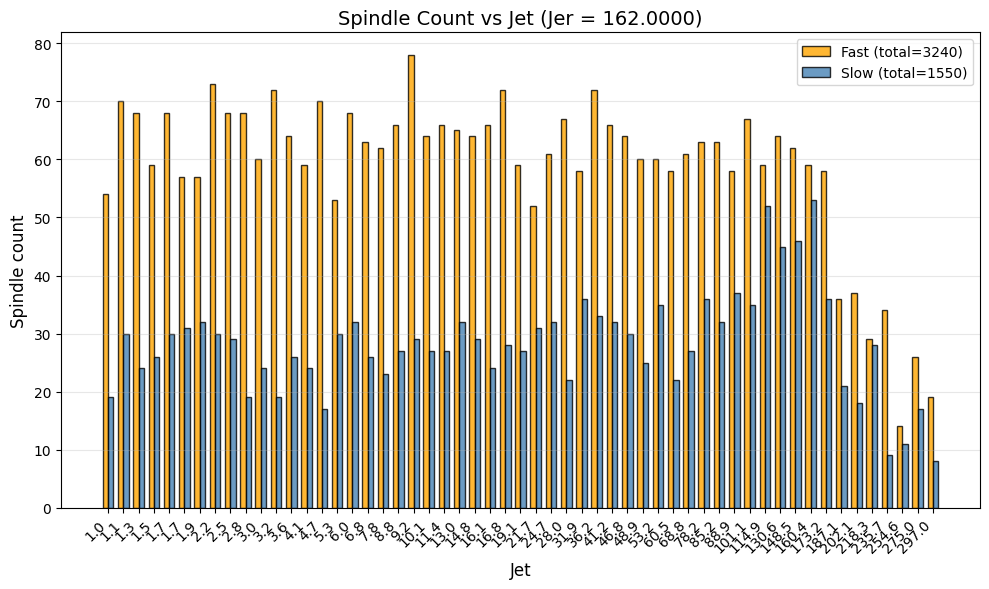


统计摘要 (Jer = 162.0000)
       Jet     Fast     Slow    Total
--------------------------------------
       1.0       54       19       73
       1.1       70       30      100
       1.3       68       24       92
       1.5       59       26       85
       1.7       68       30       98
       1.7       57       31       88
       1.9       57       32       89
       2.2       73       30      103
       2.5       68       29       97
       2.8       68       19       87
       3.0       60       24       84
       3.2       72       19       91
       3.6       64       26       90
       4.1       59       24       83
       4.7       70       17       87
       5.3       53       30       83
       6.0       68       32      100
       6.8       63       26       89
       7.8       62       23       85
       8.8       66       27       93
       9.2       78       29      107
      10.1       64       27       91
      11.4       66       27       93
      13.0       65       

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近 71.3 的 Jer 值 ==========

all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

# ========== 统计每个 Jet 下的快慢纺锤波个数 ==========
jet_vals = []
fast_counts = []
slow_counts = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    
    jet_vals.append(jet_val)
    fast_counts.append(fast_count)
    slow_counts.append(slow_count)

jet_vals = np.array(jet_vals)
fast_counts = np.array(fast_counts)
slow_counts = np.array(slow_counts)

# ========== 画图：快慢纺锤波个数随 Jet 变化 ==========
fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
x = np.arange(len(jet_vals))

ax.bar(x - width/2, fast_counts, width, color='orange', edgecolor='black', 
       label=f'Fast (total={sum(fast_counts)})', alpha=0.8)
ax.bar(x + width/2, slow_counts, width, color='steelblue', edgecolor='black', 
       label=f'Slow (total={sum(slow_counts)})', alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title(f'Spindle Count vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in jet_vals], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)
print(f"{'Jet':>10} {'Fast':>8} {'Slow':>8} {'Total':>8}")
print("-"*38)
for j, fc, sc in zip(jet_vals, fast_counts, slow_counts):
    print(f"{j:>10.1f} {fc:>8} {sc:>8} {fc+sc:>8}")
print("-"*38)
print(f"{'Total':>10} {sum(fast_counts):>8} {sum(slow_counts):>8} {sum(fast_counts)+sum(slow_counts):>8}")

#### 像分析其它参数一样分析Jet

加载文件: spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv
分析参数: Jet
检测到新增列: ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp']
Jet 值: [1.0, 1.1368, 1.2923, 1.4691, 1.6701, 1.743, 1.8986, 2.1583, 2.4536, 2.7892, 3.0381, 3.1708, 3.6046, 4.0977, 4.6583, 5.2955, 6.02, 6.8435, 7.7797, 8.844, 9.2302, 10.0539, 11.4293, 12.9929, 14.7704, 16.0885, 16.791, 19.0881, 21.6994, 24.6679, 28.0426, 31.8789, 36.24, 41.1978, 46.8337, 48.8788, 53.2407, 60.5242, 68.8042, 78.2168, 85.1968, 88.9171, 101.0812, 114.9095, 130.6295, 148.5, 160.3889, 173.2296, 187.0983, 202.0773, 218.2556, 235.7291, 254.6015, 274.9848, 297.0]

按 seed 统计后的结果示例:
   Jet  seed  type  total_duration  count  mean_freq  std_freq  mean_duration  \
0  1.0     1  fast          2.8472      4  13.522059  0.615314       0.711800   
1  1.0     1  slow          2.1903      6  10.617013  1.046574       0.365050   
2  1.0     2  fast          4.8794      6  13.867523  0.489229       0.813233   
3  1.0     2  slow    

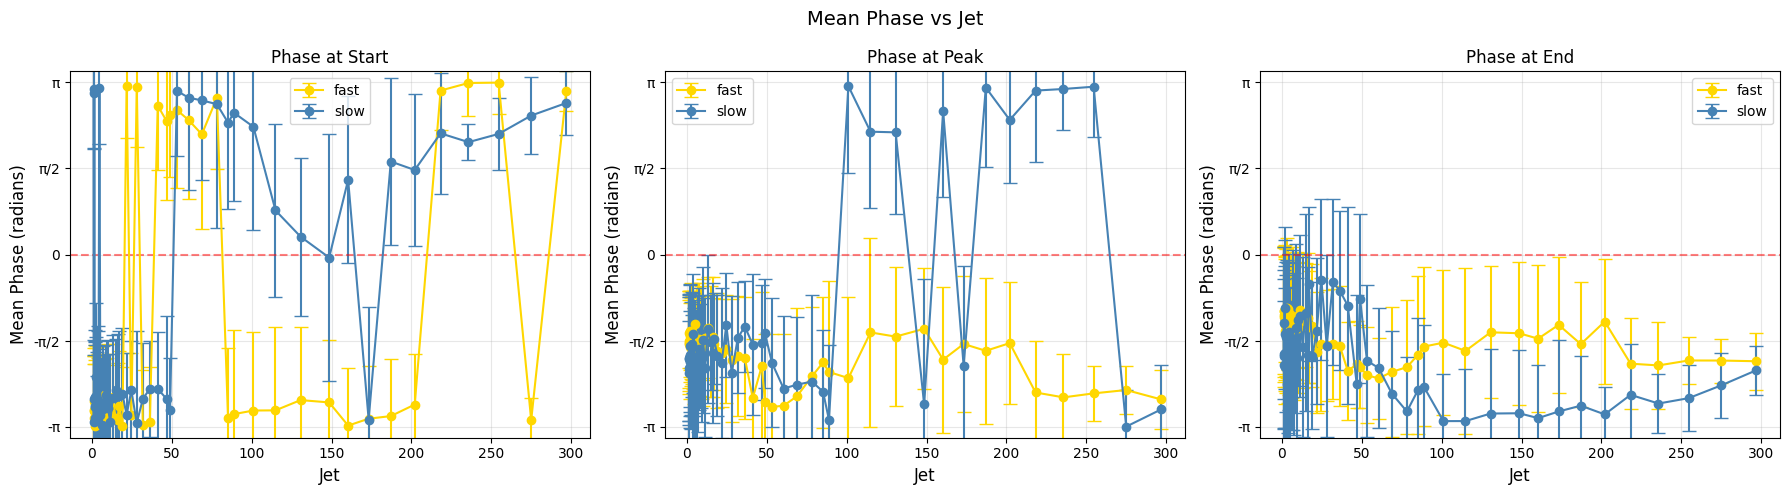

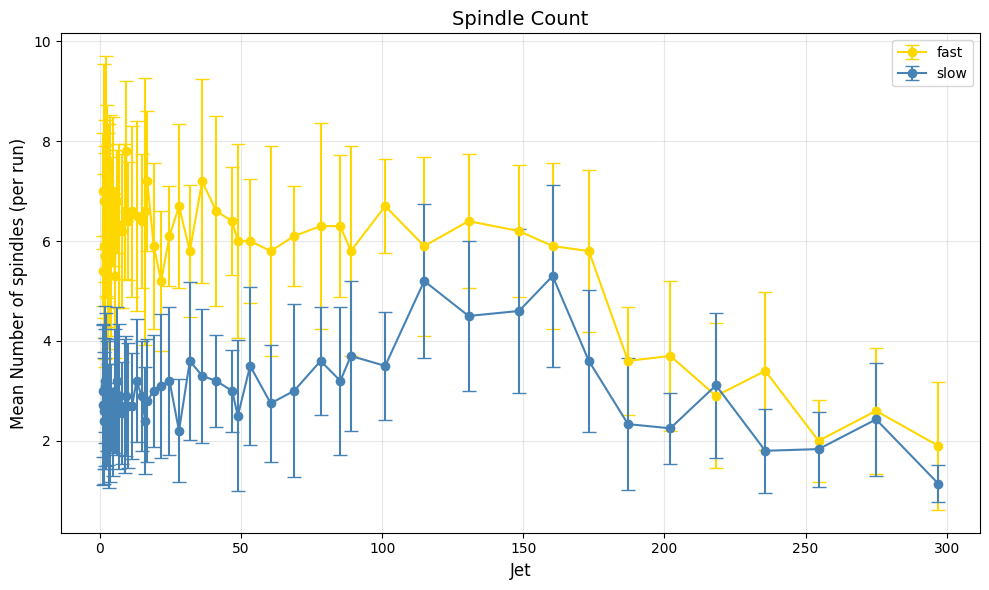

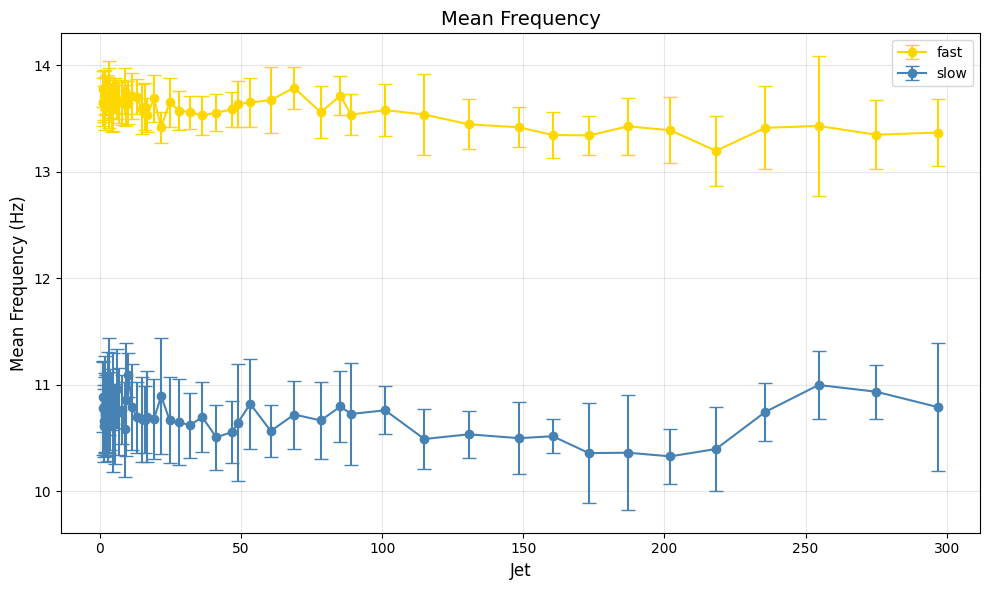

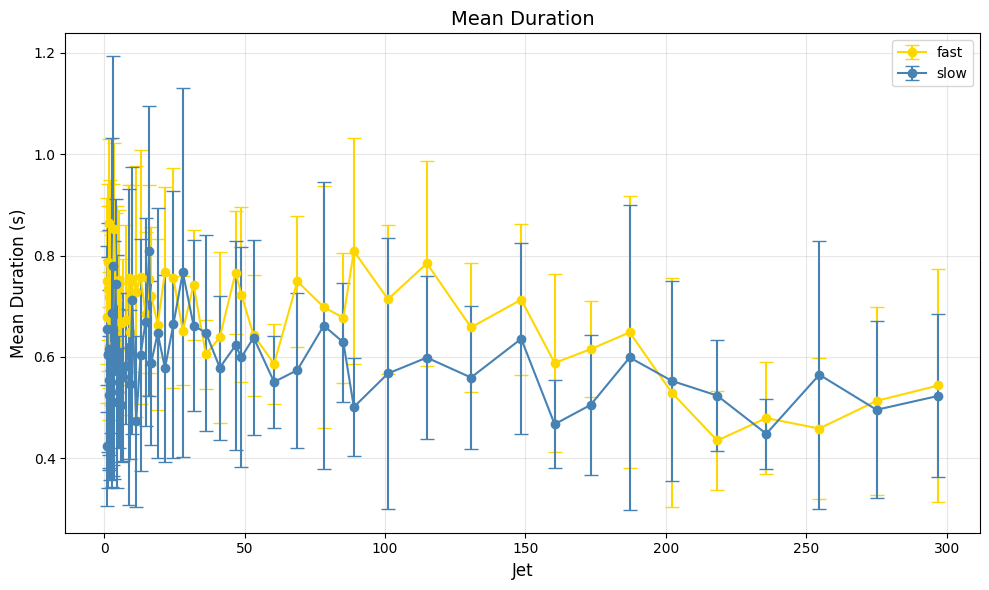

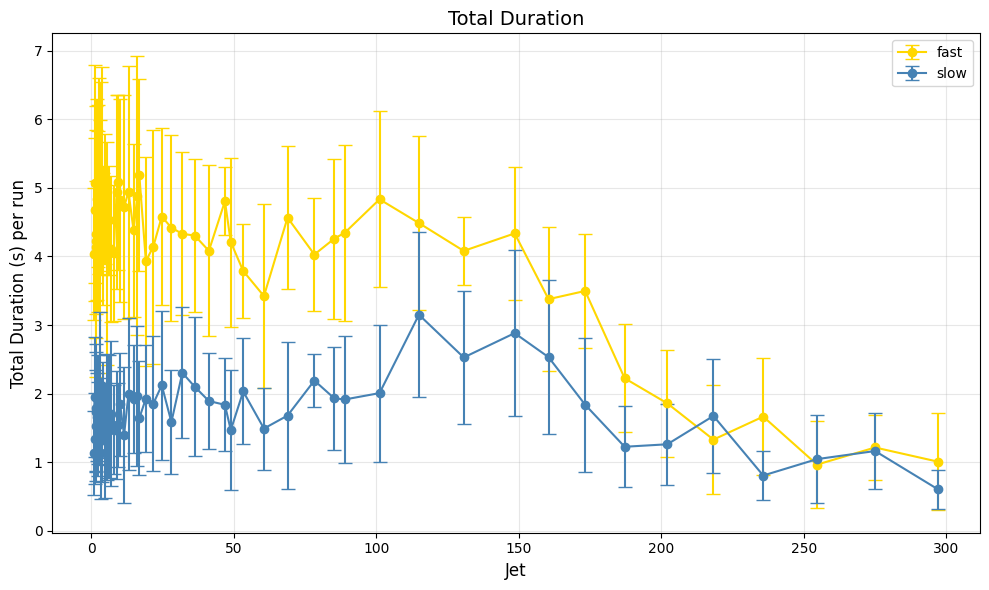

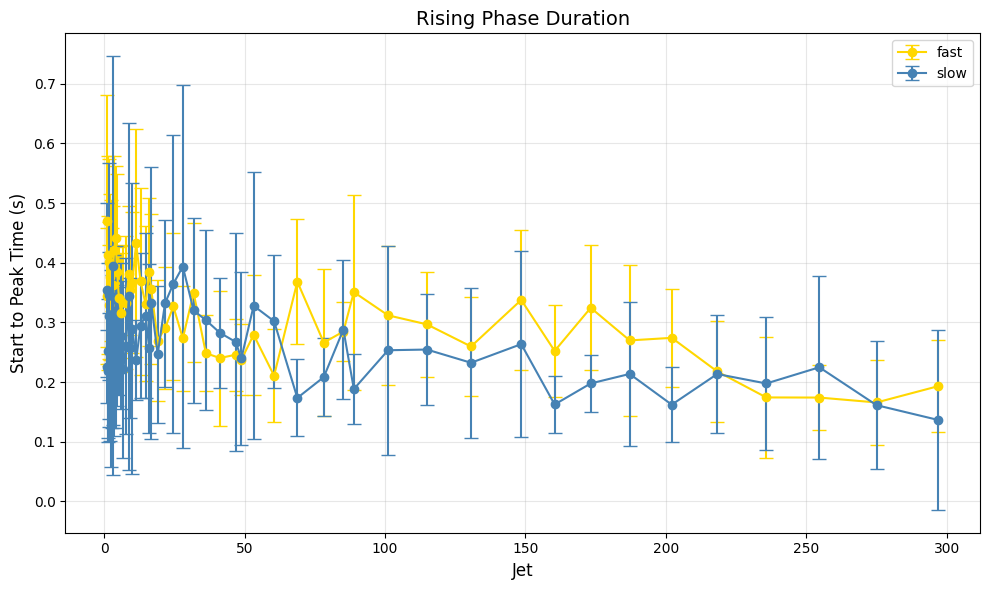

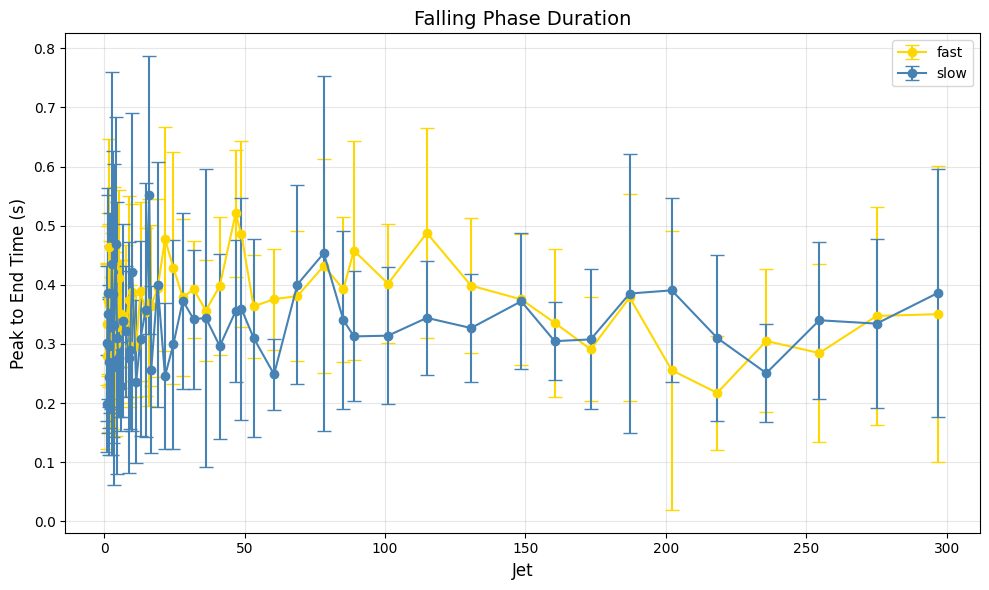

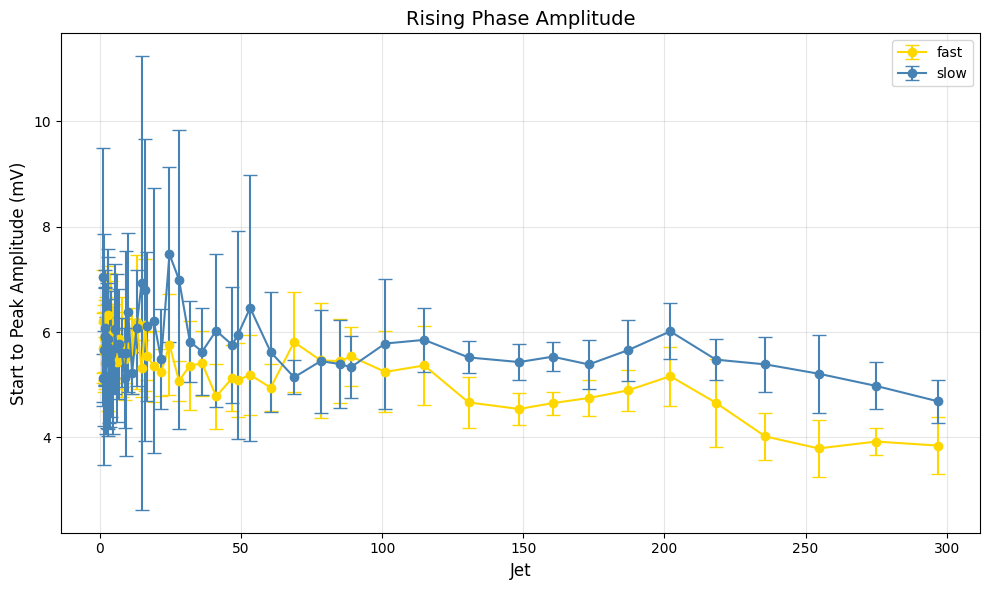

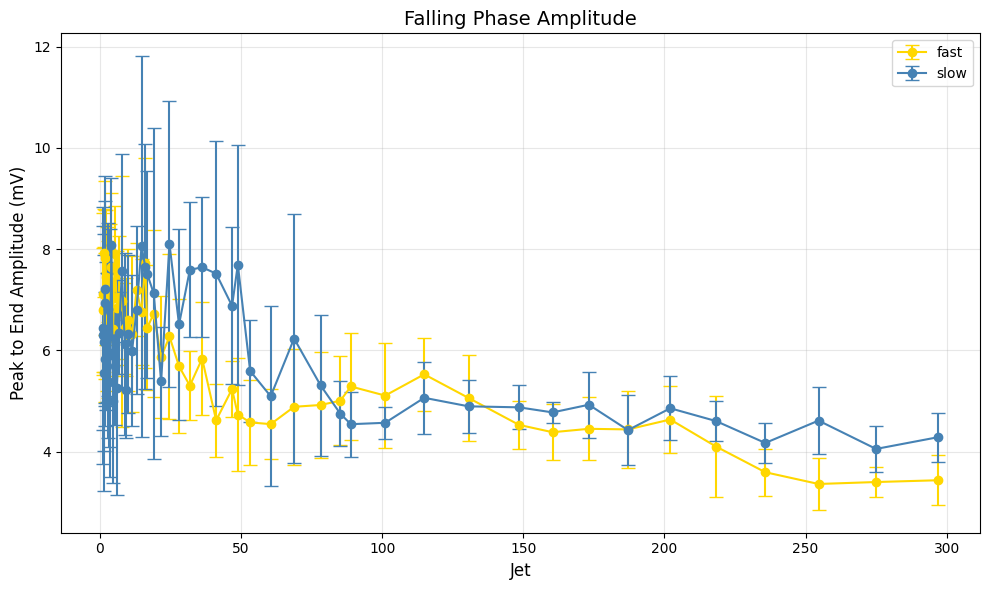


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  Jet=1.00: seeds=10, count=5.4±0.7, rise_time=0.470±0.211s, fall_time=0.279±0.157s, rise_amp=6.206±0.974mV, fall_amp=6.800±1.224mV, phase=-1.611±0.941rad
  Jet=1.14: seeds=10, count=7.0±1.2, rise_time=0.344±0.114s, fall_time=0.334±0.104s, rise_amp=5.699±0.671mV, fall_amp=7.119±1.603mV, phase=-1.571±0.912rad
  Jet=1.29: seeds=10, count=6.8±2.7, rise_time=0.414±0.166s, fall_time=0.373±0.127s, rise_amp=5.880±0.638mV, fall_amp=7.924±0.876mV, phase=-1.425±0.644rad
  Jet=1.47: seeds=10, count=5.9±1.4, rise_time=0.350±0.130s, fall_time=0.385±0.137s, rise_amp=5.621±0.752mV, fall_amp=6.812±1.237mV, phase=-1.631±0.801rad
  Jet=1.67: seeds=10, count=6.8±1.6, rise_time=0.330±0.100s, fall_time=0.291±0.141s, rise_amp=5.418±0.495mV, fall_amp=6.446±1.473mV, phase=-1.682±0.954rad
  Jet=1.74: seeds=10, count=5.7±2.2, rise_time=0.353±0.115s, fall_time=0.366±0.138s, rise_amp=5.619±0.546mV, fall_amp=7.101±1.668mV, phase=-1.557±0.678rad
  Jet=1.90: seeds=10, count=5

In [12]:
### 由于Jet的值太多，把每一张都分开画了
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 只需要改这一个参数 ==========
PARAM_TYPE = "Jet"   # 改为 "Jet"
# ======================================

# 根据 PARAM_TYPE 自动生成所有配置
PARAM_CONFIG = {
    "mue_ext_mean": {
        "file": "spindles_mue_ext_mean_explore_valid_limited.csv",
        "xlabel": "mue_ext_mean",
        "save_prefix": "mue_ext_mean",
    },
    "tau_ou": {
        "file": "spindles_tau_ou_explore_valid_limited.csv",
        "xlabel": "tau_ou (ms)",
        "save_prefix": "tau_ou",
    },
    "tau_se": {
        "file": "spindles_tau_se_explore_valid_limited.csv",
        "xlabel": "tau_se (ms)",
        "save_prefix": "tau_se",
    },
    "cee": {
        "file": "spindles_cee_explore_valid_limited.csv",
        "xlabel": "cee",
        "save_prefix": "cee",
    },
    "cie": {
        "file": "spindles_cie_explore_valid_limited.csv",
        "xlabel": "cie",
        "save_prefix": "cie",
    },
    "cie_c2tsc0x8_Jrt0x6": {
        "file": "spindles_cie_c2tsc0x8_Jrt0x6_explore_valid_limited.csv",
        "xlabel": "cie (c2tsc=0.8, Jrt=-0.6)",
        "save_prefix": "cie_c2tsc0x8_Jrt0x6",
    },
    "Jet": {
        "file": "spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv",
        "xlabel": "Jet",
        "save_prefix": "Jet",
    },
    "Jet_Jrta_0x8": {
        "file": "spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv",
        "xlabel": "Jet (Jrt=-0.8)",
        "save_prefix": "Jet_Jrta_0x8",
    },
}

# 获取当前配置
config = PARAM_CONFIG.get(PARAM_TYPE, PARAM_CONFIG[PARAM_TYPE])
DATA_FILE = config["file"]
X_LABEL = config["xlabel"]
SAVE_PREFIX = config["save_prefix"]
PARAM_NAME = PARAM_TYPE

print(f"加载文件: {DATA_FILE}")
print(f"分析参数: {PARAM_NAME}")

df = pd.read_csv(f"data/analysis_data/{DATA_FILE}")

# 检查是否有新增的列
new_cols = ['start_to_peak_time', 'peak_to_end_time', 'start_to_peak_amp', 'peak_to_end_amp']
has_new_cols = all(col in df.columns for col in new_cols)
if has_new_cols:
    print(f"检测到新增列: {new_cols}")
else:
    print(f"警告: 未检测到新增列，可能 CSV 未包含 start_to_peak 等字段")

phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

def circular_stats(phases):
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 先计算每个 seed 的统计量，再求平均 ==========
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
    mean_start_to_peak_time=('start_to_peak_time', 'mean'),
    std_start_to_peak_time=('start_to_peak_time', 'std'),
    mean_peak_to_end_time=('peak_to_end_time', 'mean'),
    std_peak_to_end_time=('peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('peak_to_end_amp', 'std'),
).reset_index()

summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
    mean_start_to_peak_time=('mean_start_to_peak_time', 'mean'),
    std_start_to_peak_time=('mean_start_to_peak_time', 'std'),
    mean_peak_to_end_time=('mean_peak_to_end_time', 'mean'),
    std_peak_to_end_time=('mean_peak_to_end_time', 'std'),
    mean_start_to_peak_amp=('mean_start_to_peak_amp', 'mean'),
    std_start_to_peak_amp=('mean_start_to_peak_amp', 'std'),
    mean_peak_to_end_amp=('mean_peak_to_end_amp', 'mean'),
    std_peak_to_end_amp=('mean_peak_to_end_amp', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图1：平均相位（三张子图在一行）==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2-5：四张汇总图（各单独一张）==========

# 图2：平均纺锤波数量
fig, ax = plt.subplots(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 图3：平均频率
fig, ax = plt.subplots(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 图4：平均时长
fig, ax = plt.subplots(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 图5：总时长
fig, ax = plt.subplots(figsize=(10, 6))
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图6-9：新增四张子图（各单独一张）==========
if has_new_cols:
    # 图6：上升段时间 (start_to_peak_time)
    fig, ax = plt.subplots(figsize=(10, 6))
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_time'], 
                    yerr=subset['std_start_to_peak_time'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Start to Peak Time (s)', fontsize=12)
    ax.set_title('Rising Phase Duration', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 图7：下降段时间 (peak_to_end_time)
    fig, ax = plt.subplots(figsize=(10, 6))
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_time'], 
                    yerr=subset['std_peak_to_end_time'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Peak to End Time (s)', fontsize=12)
    ax.set_title('Falling Phase Duration', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 图8：上升段振幅 (start_to_peak_amp)
    fig, ax = plt.subplots(figsize=(10, 6))
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_start_to_peak_amp'], 
                    yerr=subset['std_start_to_peak_amp'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Start to Peak Amplitude (mV)', fontsize=12)
    ax.set_title('Rising Phase Amplitude', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 图9：下降段振幅 (peak_to_end_amp)
    fig, ax = plt.subplots(figsize=(10, 6))
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[summary_stats['type'] == spindle_type]
        ax.errorbar(subset[PARAM_NAME], subset['mean_peak_to_end_amp'], 
                    yerr=subset['std_peak_to_end_amp'],
                    fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Peak to End Amplitude (mV)', fontsize=12)
    ax.set_title('Falling Phase Amplitude', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n跳过图6-9：CSV 中未找到新增列")

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            mean_rise_time = subset['mean_start_to_peak_time'].mean() if 'mean_start_to_peak_time' in subset.columns else np.nan
            std_rise_time = subset['mean_start_to_peak_time'].std() if 'mean_start_to_peak_time' in subset.columns else np.nan
            mean_fall_time = subset['mean_peak_to_end_time'].mean() if 'mean_peak_to_end_time' in subset.columns else np.nan
            std_fall_time = subset['mean_peak_to_end_time'].std() if 'mean_peak_to_end_time' in subset.columns else np.nan
            mean_rise_amp = subset['mean_start_to_peak_amp'].mean() if 'mean_start_to_peak_amp' in subset.columns else np.nan
            std_rise_amp = subset['mean_start_to_peak_amp'].std() if 'mean_start_to_peak_amp' in subset.columns else np.nan
            mean_fall_amp = subset['mean_peak_to_end_amp'].mean() if 'mean_peak_to_end_amp' in subset.columns else np.nan
            std_fall_amp = subset['mean_peak_to_end_amp'].std() if 'mean_peak_to_end_amp' in subset.columns else np.nan
            
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                if has_new_cols:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                          f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                          f"phase={mean_phase:6.3f}±{std_phase:.3f}rad")
                else:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, "
                          f"dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                if has_new_cols:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"rise_time={mean_rise_time:.3f}±{std_rise_time:.3f}s, fall_time={mean_fall_time:.3f}±{std_fall_time:.3f}s, "
                          f"rise_amp={mean_rise_amp:.3f}±{std_rise_amp:.3f}mV, fall_amp={mean_fall_amp:.3f}±{std_fall_amp:.3f}mV, "
                          f"no valid phase")
                else:
                    print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, "
                          f"total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, "
                          f"dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")

#### EXTRA: statistic analysis

In [2]:
# ================================================================
# ========== 新增：统计分析部分 ==========
# ================================================================
from scipy.stats import spearmanr, pearsonr
import statsmodels.formula.api as smf

print("\n\n" + "#"*70)
print("# 统计分析：检查 fast 与 slow 纺锤波数量随 Jet 的趋势")
print("#"*70)

# 只保留 count 这一列用于统计（你也可以把 'count' 换成其他指标）
STAT_COL = 'count'   # 可改为 'mean_freq', 'mean_duration', 'total_duration' 等

print(f"\n使用的指标: {STAT_COL}")
print(f"Jet 值: {param_values}")
print(f"每个 Jet 值下的 seed 数（fast/slow）:")
print(seed_stats.groupby([PARAM_NAME, 'type']).size().unstack())

# ---------- 方法 1：Spearman 相关（用每个 Jet 的均值） ----------
print("\n" + "="*70)
print("方法 1: Spearman 相关 (对每个 Jet 的均值)")
print("="*70)

for spindle_type in ['fast', 'slow']:
    sub = summary_stats[summary_stats['type'] == spindle_type].sort_values(PARAM_NAME)
    x = sub[PARAM_NAME].values
    y = sub[f'mean_{STAT_COL}'].values if f'mean_{STAT_COL}' in sub.columns else sub[STAT_COL].values
    rho, p = spearmanr(x, y)
    print(f"  {spindle_type:5s}: Spearman rho = {rho:+.3f}, p = {p:.4f}"
          f"  {'*显著*' if p < 0.05 else '不显著'}")

# ---------- 方法 2：线性回归（每个 type 单独拟合） ----------
print("\n" + "="*70)
print("方法 2: 线性回归 (每个 type 单独拟合, seed 水平数据)")
print("="*70)

try:
    import statsmodels.api as sm
    for spindle_type in ['fast', 'slow']:
        sub = seed_stats[seed_stats['type'] == spindle_type].dropna(subset=[STAT_COL, PARAM_NAME])
        X = sm.add_constant(sub[PARAM_NAME].values)
        y = sub[STAT_COL].values
        model = sm.OLS(y, X).fit()
        slope = model.params[1]
        pval = model.pvalues[1]
        r2 = model.rsquared
        print(f"  {spindle_type:5s}: slope = {slope:+.3f}, p = {pval:.4f}, R² = {r2:.3f}"
              f"  {'*显著*' if pval < 0.05 else '不显著'}")
except ImportError:
    print("  需要 statsmodels: pip install statsmodels")

# ---------- 方法 3：混合效应模型（推荐） ----------
print("\n" + "="*70)
print("方法 3: 线性混合效应模型 (seed 作为随机效应)")
print("="*70)
print("模型: count ~ Jet * type + (1|seed)")

try:
    # 需要把 type 变成分类变量
    seed_stats_stat = seed_stats.dropna(subset=[STAT_COL, PARAM_NAME]).copy()
    seed_stats_stat['type'] = seed_stats_stat['type'].astype('category')

    model = smf.mixedlm(
        f"{STAT_COL} ~ {PARAM_NAME} * C(type)",
        seed_stats_stat,
        groups=seed_stats_stat["seed"]
    )
    result = model.fit()
    print(result.summary())

    print("\n--- 关键系数 ---")
    print(f"Jet 主效应 (fast 的斜率):        {result.params.get(PARAM_NAME, np.nan):+.4f}, "
          f"p = {result.pvalues.get(PARAM_NAME, np.nan):.4f}")
    interaction_key = [k for k in result.params.index if ':' in k]
    if interaction_key:
        k = interaction_key[0]
        print(f"Jet × type 交互项 (slow - fast):  {result.params[k]:+.4f}, "
              f"p = {result.pvalues[k]:.4f}")
        print("  -> 交互项显著 = fast 和 slow 随 Jet 的变化趋势不同")
except Exception as e:
    print(f"  混合模型出错: {e}")
    print("  可能需要: pip install statsmodels")

# ---------- 方法 4（可选）：置换检验 / bootstrap ----------
print("\n" + "="*70)
print("方法 4 (可选): Bootstrap 置信区间 (对 Spearman rho)")
print("="*70)

np.random.seed(42)
n_boot = 2000
for spindle_type in ['fast', 'slow']:
    sub = seed_stats[seed_stats['type'] == spindle_type].dropna(subset=[STAT_COL, PARAM_NAME])
    rho_boot = []
    for _ in range(n_boot):
        # 对 seed 进行有放回重采样
        seeds = sub['seed'].unique()
        sampled_seeds = np.random.choice(seeds, size=len(seeds), replace=True)
        boot_df = pd.concat([sub[sub['seed'] == s] for s in sampled_seeds])
        # 每个 Jet 取均值
        boot_summary = boot_df.groupby(PARAM_NAME)[STAT_COL].mean().reset_index()
        if len(boot_summary) > 2:
            r, _ = spearmanr(boot_summary[PARAM_NAME], boot_summary[STAT_COL])
            if not np.isnan(r):
                rho_boot.append(r)
    if len(rho_boot) > 0:
        lo, hi = np.percentile(rho_boot, [2.5, 97.5])
        print(f"  {spindle_type:5s}: Spearman rho 95% CI = [{lo:+.3f}, {hi:+.3f}]"
              f"  {'(不含 0, 显著)' if lo*hi > 0 else '(含 0, 不显著)'}")

print("\n完成。")

ModuleNotFoundError: No module named 'statsmodels'

#### 追加：不同Jet下的频谱图

总纺锤波数: 4790
Jet 范围: 1.00 ~ 297.00
Jer 范围: 162.00 ~ 162.00

目标 Jer: 162, 实际最近值: 162.0000
筛选后纺锤波数: 4790
Jet 值: [1.0, 1.1368, 1.2923, 1.4691, 1.6701, 1.743, 1.8986, 2.1583, 2.4536, 2.7892, 3.0381, 3.1708, 3.6046, 4.0977, 4.6583, 5.2955, 6.02, 6.8435, 7.7797, 8.844, 9.2302, 10.0539, 11.4293, 12.9929, 14.7704, 16.0885, 16.791, 19.0881, 21.6994, 24.6679, 28.0426, 31.8789, 36.24, 41.1978, 46.8337, 48.8788, 53.2407, 60.5242, 68.8042, 78.2168, 85.1968, 88.9171, 101.0812, 114.9095, 130.6295, 148.5]

选中的 Jet 值: [1.0, 1.8986, 4.0977, 8.844, 16.791, 19.0881, 21.6994, 24.6679, 28.0426, 31.8789, 36.24, 41.1978, 46.8337, 48.8788, 53.2407, 60.5242, 68.8042, 78.2168, 85.1968, 88.9171, 101.0812, 114.9095, 130.6295, 148.5]
找到 550 个文件
Jet=1.00: 10 个 seed
Jet=1.90: 10 个 seed
Jet=4.10: 10 个 seed
Jet=8.84: 10 个 seed
Jet=16.79: 10 个 seed
Jet=19.09: 10 个 seed
Jet=21.70: 10 个 seed
Jet=24.67: 10 个 seed
Jet=28.04: 10 个 seed
Jet=31.88: 10 个 seed
Jet=36.24: 10 个 seed
Jet=41.20: 10 个 seed
Jet=46.83: 10 个 seed
Jet=48.

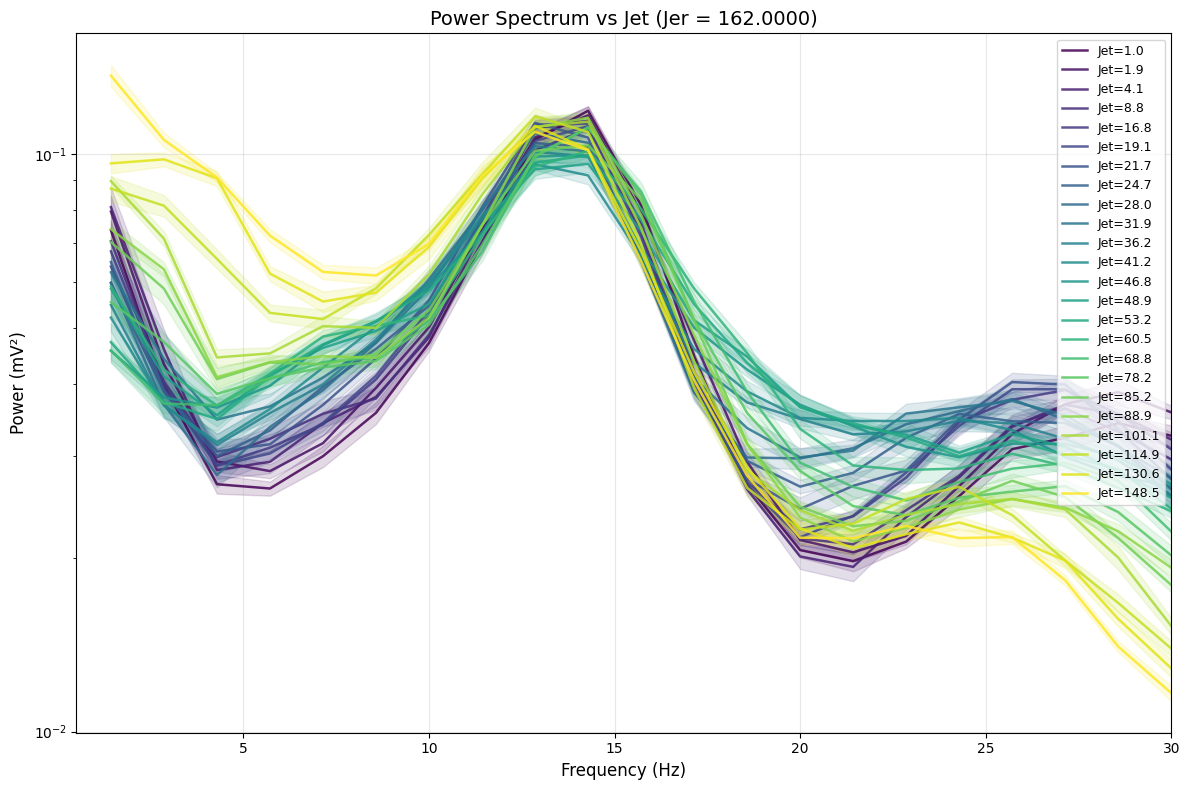

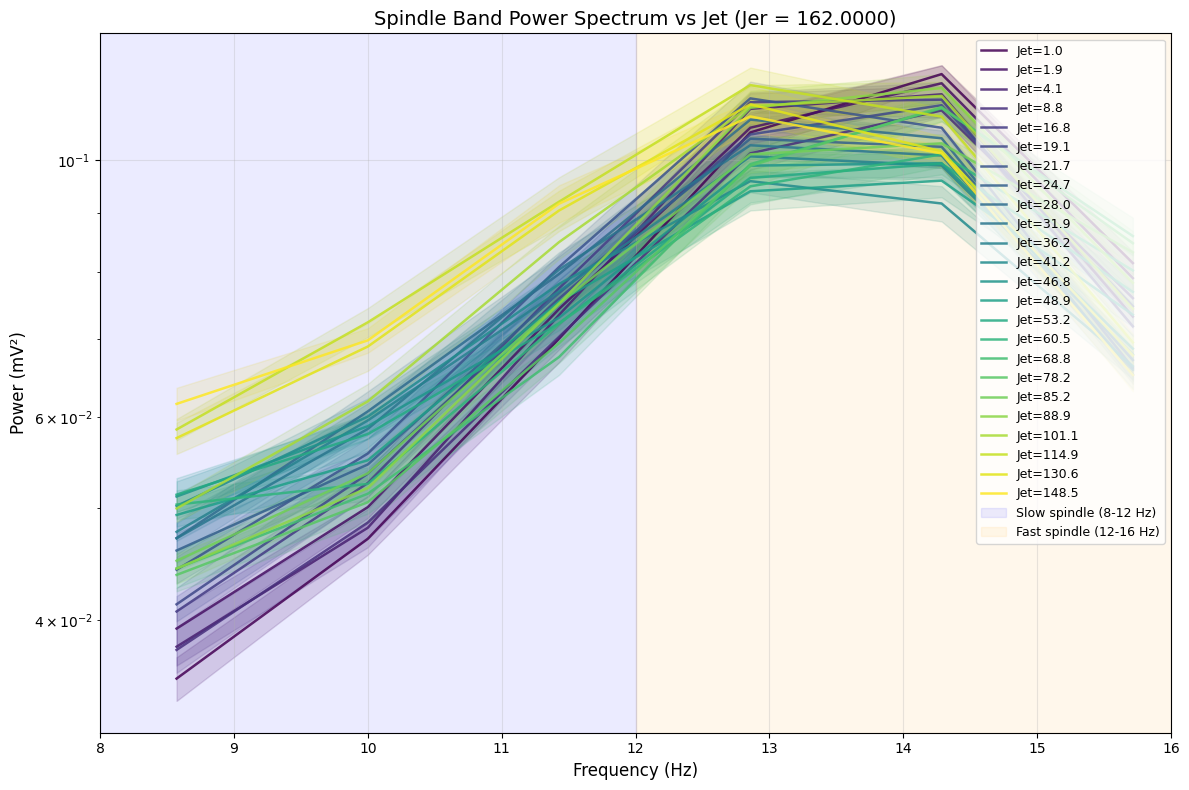

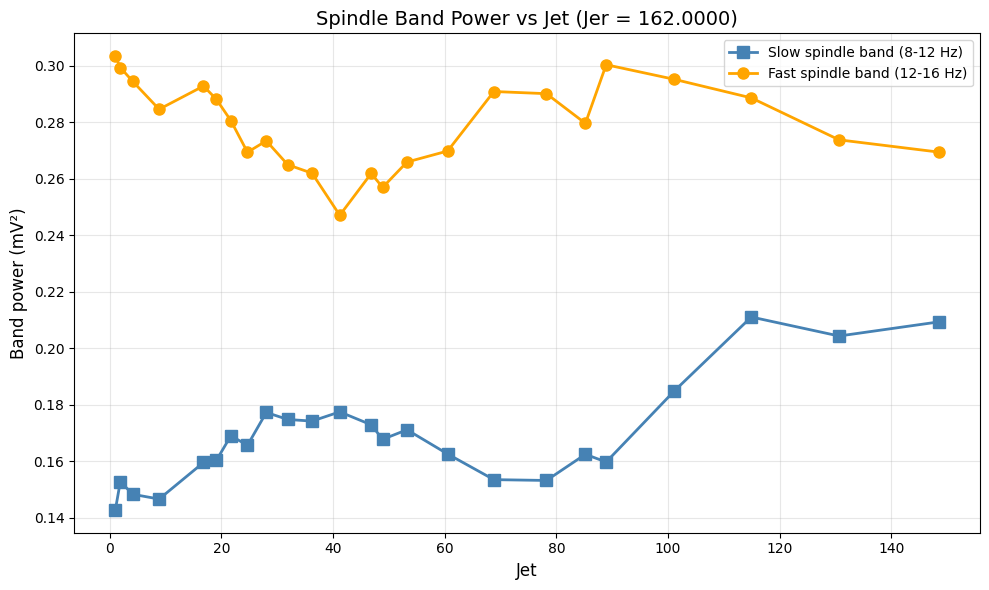


纺锤波频段总功率 (Jer = 162.0000)
Jet=1.0: slow=0.1428 mV², fast=0.3034 mV²
Jet=1.9: slow=0.1529 mV², fast=0.2993 mV²
Jet=4.1: slow=0.1484 mV², fast=0.2945 mV²
Jet=8.8: slow=0.1467 mV², fast=0.2845 mV²
Jet=16.8: slow=0.1596 mV², fast=0.2928 mV²
Jet=19.1: slow=0.1603 mV², fast=0.2881 mV²
Jet=21.7: slow=0.1691 mV², fast=0.2805 mV²
Jet=24.7: slow=0.1657 mV², fast=0.2694 mV²
Jet=28.0: slow=0.1773 mV², fast=0.2734 mV²
Jet=31.9: slow=0.1748 mV², fast=0.2649 mV²
Jet=36.2: slow=0.1742 mV², fast=0.2619 mV²
Jet=41.2: slow=0.1775 mV², fast=0.2471 mV²
Jet=46.8: slow=0.1729 mV², fast=0.2619 mV²
Jet=48.9: slow=0.1678 mV², fast=0.2569 mV²
Jet=53.2: slow=0.1712 mV², fast=0.2659 mV²
Jet=60.5: slow=0.1626 mV², fast=0.2698 mV²
Jet=68.8: slow=0.1535 mV², fast=0.2908 mV²
Jet=78.2: slow=0.1532 mV², fast=0.2901 mV²
Jet=85.2: slow=0.1625 mV², fast=0.2796 mV²
Jet=88.9: slow=0.1598 mV², fast=0.3003 mV²
Jet=101.1: slow=0.1848 mV², fast=0.2952 mV²
Jet=114.9: slow=0.2111 mV², fast=0.2886 mV²
Jet=130.6: slow=0.2043 mV², f

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
import matplotlib.ticker as ticker

# ========== 1. 读取 CSV ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_0x8_explore.csv")

if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 2. 找到最接近 162 的 Jer 值 ==========
target_Jer = 162
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 3. 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]
print(f"筛选后纺锤波数: {len(jer_filtered)}")

# ========== 4. 获取 Jet 值 ==========
all_Jet_values = sorted([v for v in jer_filtered['Jet'].unique() if v < 150])
print(f"Jet 值: {all_Jet_values}")

# 选择代表性的 Jet 值（避免太多看不清）
def select_jet_values(values, threshold=17, n_select_low=5):
    values_sorted = sorted(values)
    low_values = [v for v in values_sorted if v < threshold]
    high_values = [v for v in values_sorted if v >= threshold]
    
    if len(low_values) > n_select_low:
        indices = np.linspace(0, len(low_values) - 1, n_select_low, dtype=int)
        selected_low = [low_values[i] for i in indices]
    else:
        selected_low = low_values
    
    return sorted(selected_low + high_values)

Jet_values = select_jet_values(all_Jet_values, threshold=17, n_select_low=5)
print(f"\n选中的 Jet 值: {Jet_values}")

'''
# ========== 选择代表性的 Jet 值 ==========
# 方案：均匀选取 6 个
Jet_values = np.linspace(all_Jet_values[0], all_Jet_values[-1], 6).tolist()
Jet_values = [round(v, 1) for v in Jet_values]
Jet_values = sorted(set([min(all_Jet_values, key=lambda x: abs(x - v)) for v in Jet_values]))
print(f"\n选中的 Jet 值: {Jet_values}")

'''

# ========== 5. 参数设置 ==========
sf = 10000
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_0x8"
nperseg = int(sf * 0.7)
freq_range = (0.5, 30)

# ========== 6. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for f in file_list:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    try:
        Jet_val = float(parts[5])
        Jer_val = float(parts[7])
        seed = int(parts[9])
        file_map[(Jet_val, Jer_val, seed)] = f
    except:
        continue

print(f"找到 {len(file_map)} 个文件")

# ========== 7. 按 Jet 分组计算平均 PSD ==========
freqs = None
psd_by_Jet = {}

for Jet_val in Jet_values:
    psd_list = []
    
    # 找该 Jet 下所有 seed（固定 Jer = closest_Jer）
    seeds = jer_filtered[jer_filtered['Jet'] == Jet_val]['seed'].unique()
    
    for seed in seeds:
        key = (Jet_val, closest_Jer, seed)
        if key not in file_map:
            continue
        
        data = np.load(file_map[key], allow_pickle=True).item()
        V_t = data["V_t"]
        
        f, Pxx = signal.welch(V_t, sf, nperseg=nperseg, scaling='spectrum')
        
        if freqs is None:
            freqs = f
        
        psd_list.append(Pxx)
    
    if len(psd_list) > 0:
        psd_array = np.array(psd_list)
        psd_by_Jet[Jet_val] = {
            'mean': np.mean(psd_array, axis=0),
            'std': np.std(psd_array, axis=0),
            'n': len(psd_array)
        }
        print(f"Jet={Jet_val:.2f}: {len(psd_array)} 个 seed")

# ========== 8. 画图：全频段 ==========
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jet_values)))

for i, Jet_val in enumerate(Jet_values):
    if Jet_val not in psd_by_Jet:
        continue
    data = psd_by_Jet[Jet_val]
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jet={Jet_val:.1f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title(f'Power Spectrum vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xlim(freq_range[0], freq_range[1])
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=5))
plt.tight_layout()
plt.show()

# ========== 9. 画图：纺锤波频段放大 ==========
fig, ax = plt.subplots(figsize=(12, 8))

for i, Jet_val in enumerate(Jet_values):
    if Jet_val not in psd_by_Jet:
        continue
    data = psd_by_Jet[Jet_val]
    mask = (freqs >= 8) & (freqs <= 16)
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jet={Jet_val:.1f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.axvspan(8, 12, alpha=0.08, color='blue', label='Slow spindle (8-12 Hz)')
ax.axvspan(12, 16, alpha=0.08, color='orange', label='Fast spindle (12-16 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title(f'Spindle Band Power Spectrum vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xlim(8, 16)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 10. 频段总功率 vs Jet ==========
band_power_stats = []

for Jet_val in Jet_values:
    if Jet_val not in psd_by_Jet:
        continue
    
    slow_mask = (freqs >= 8) & (freqs <= 12)
    slow_power = np.trapz(psd_by_Jet[Jet_val]['mean'][slow_mask], freqs[slow_mask])
    
    fast_mask = (freqs >= 12) & (freqs <= 16)
    fast_power = np.trapz(psd_by_Jet[Jet_val]['mean'][fast_mask], freqs[fast_mask])
    
    band_power_stats.append({
        'Jet': Jet_val,
        'slow_band_power': slow_power,
        'fast_band_power': fast_power,
    })

band_power_df = pd.DataFrame(band_power_stats)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(band_power_df['Jet'], band_power_df['slow_band_power'], 
        's-', color='steelblue', linewidth=2, markersize=8, label='Slow spindle band (8-12 Hz)')
ax.plot(band_power_df['Jet'], band_power_df['fast_band_power'], 
        'o-', color='orange', linewidth=2, markersize=8, label='Fast spindle band (12-16 Hz)')

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Band power (mV²)', fontsize=12)
ax.set_title(f'Spindle Band Power vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"纺锤波频段总功率 (Jer = {closest_Jer:.4f})")
print("="*60)
for _, row in band_power_df.iterrows():
    print(f"Jet={row['Jet']:.1f}: slow={row['slow_band_power']:.4f} mV², fast={row['fast_band_power']:.4f} mV²")